In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split

In [110]:
ds = pd.read_csv('boston_housing_clean.xlsx - Sheet1.csv')
ds


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [111]:
ds.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [112]:
ds.tail()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273,21.0,396.90,7.88,11.9


In [113]:
ds.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [114]:
ds.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.593761,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.596783,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.647423,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [115]:
ds.shape

(506, 14)

In [116]:
ds.duplicated().sum()

np.int64(0)

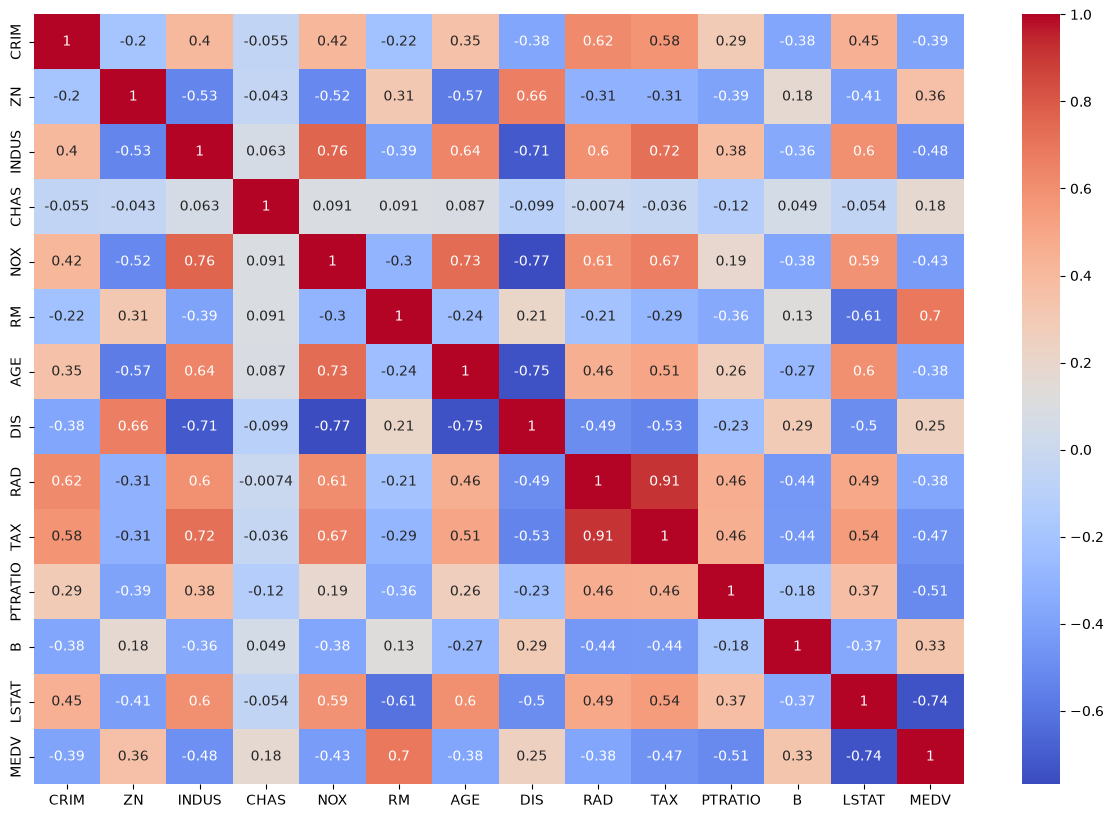

In [117]:
corr  = ds.corr(numeric_only=True)
corr

plt.figure(figsize=(15,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

Correlation with MEDV:
RM         0.695
ZN         0.360
B          0.333
DIS        0.250
CHAS       0.175
AGE       -0.377
RAD       -0.382
CRIM      -0.386
NOX       -0.427
TAX       -0.469
INDUS     -0.484
PTRATIO   -0.508
LSTAT     -0.738
Name: MEDV, dtype: float64


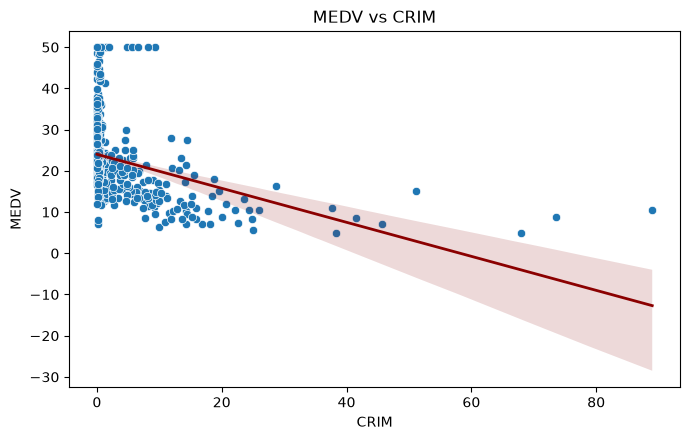

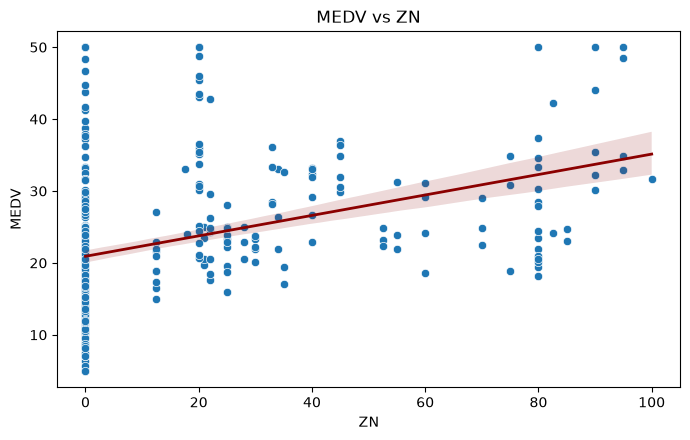

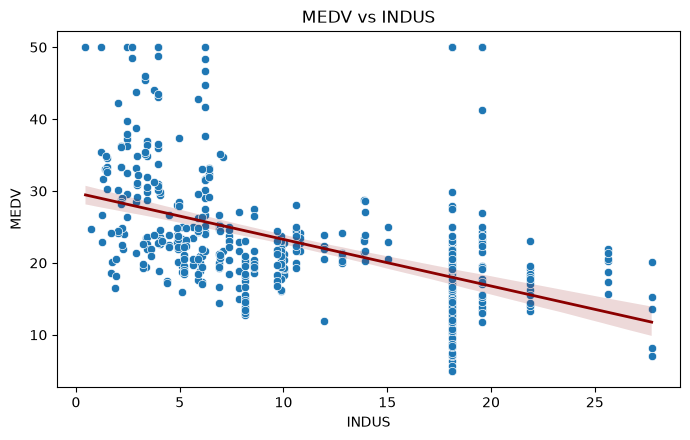

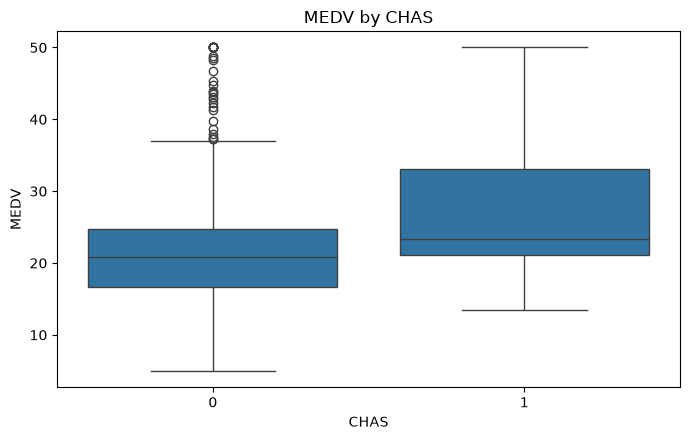

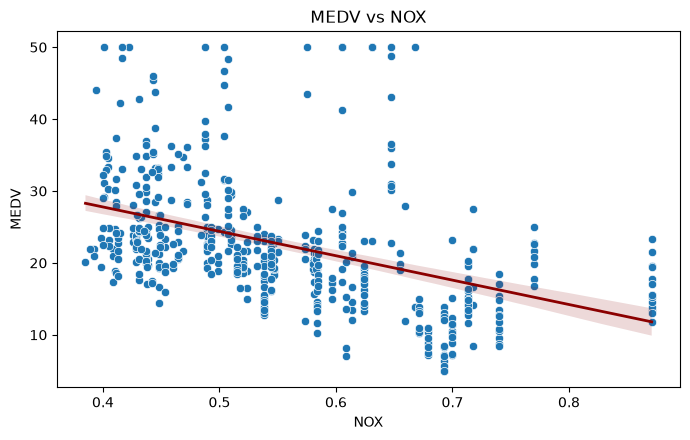

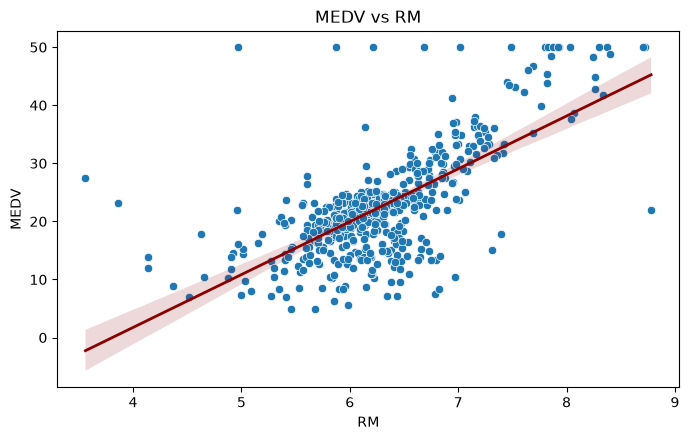

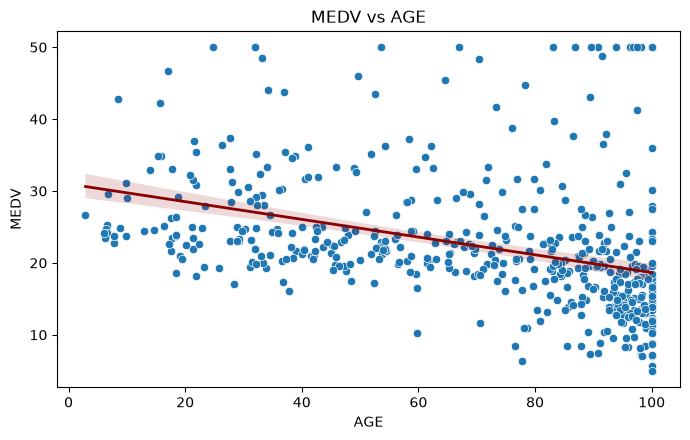

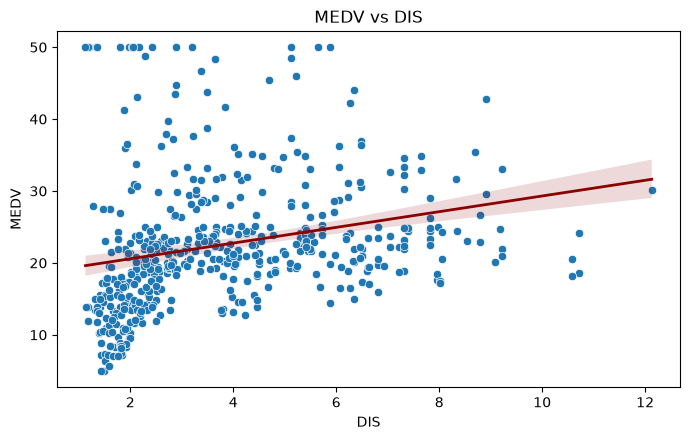

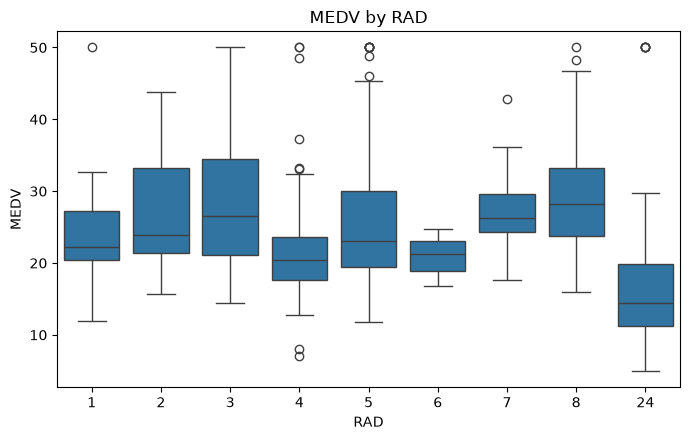

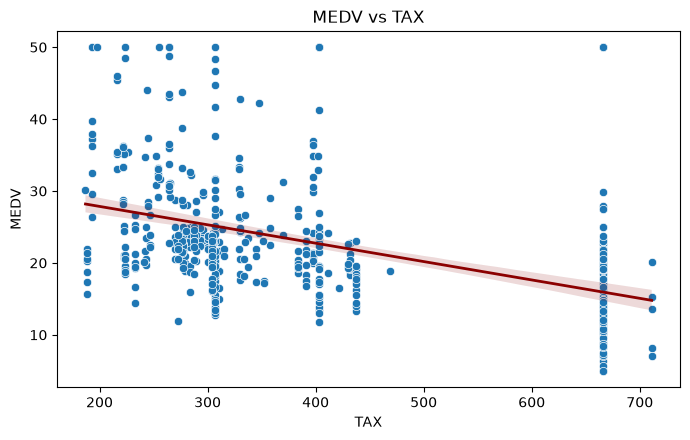

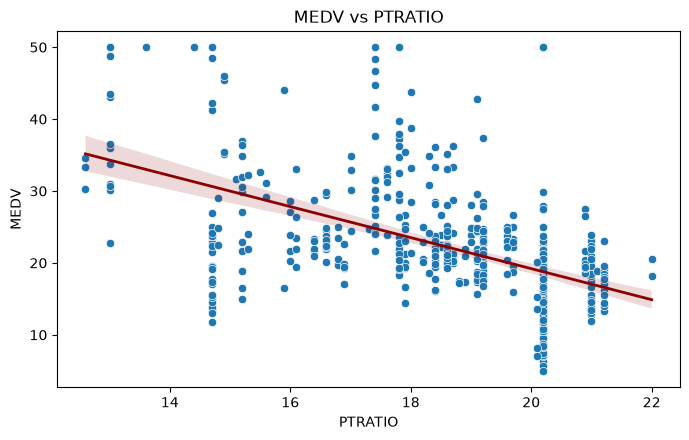

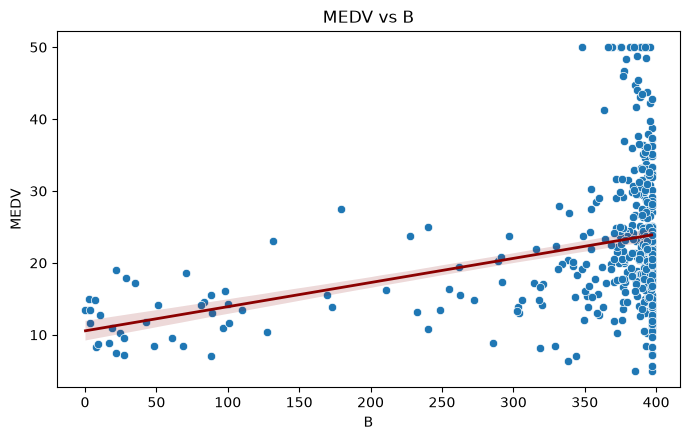

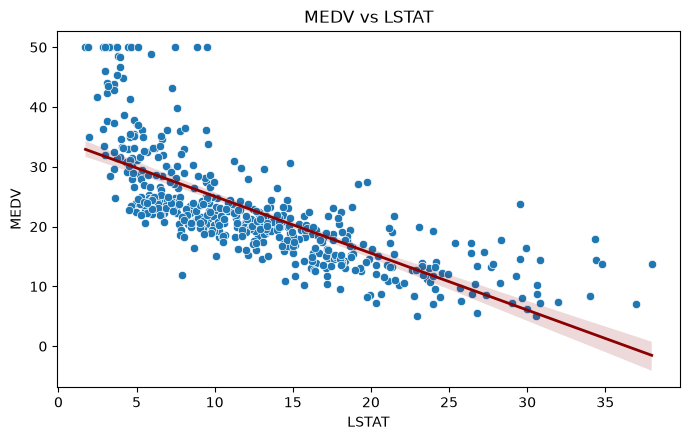

In [118]:
target_col = 'MEDV'
feature_cols = [col for col in ds.columns if col != target_col and pd.api.types.is_numeric_dtype(ds[col])]

print('Correlation with MEDV:')
print(ds[feature_cols + [target_col]].corr(numeric_only=True)[target_col].drop(target_col).sort_values(ascending=False).round(3))

for col in feature_cols:
    plt.figure(figsize=(7, 4.5))

    if ds[col].nunique() <= 10:
        sns.boxplot(data=ds, x=col, y=target_col)
        plt.title(f'{target_col} by {col}')
    else:
        sns.scatterplot(data=ds, x=col, y=target_col)
        sns.regplot(data=ds, x=col, y=target_col, scatter=False, color='darkred', line_kws={'linewidth': 2})
        plt.title(f'{target_col} vs {col}')

    plt.xlabel(col)
    plt.ylabel(target_col)
    plt.tight_layout()
    plt.show()


In [119]:
x=ds[['RM','LSTAT','PTRATIO','INDUS','NOX','AGE','TAX','CRIM']]
y=ds['MEDV']


In [120]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.15,random_state=42)

In [121]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [122]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 4.35,-0.61,-0.93,..., 0.04, 0. ,-0.07]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['RM','LSTAT','PTRATIO',...,'AGE','TAX','CRIM']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,21.01
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [123]:
print("Coefficients:")

for feature,coefficient in zip(x.columns,model.coef_):
    print(feature,":",round(coefficient,3))
    
print("Intercept: ",round(model.intercept_,3))

Coefficients:
RM : 4.354
LSTAT : -0.606
PTRATIO : -0.926
INDUS : 0.063
NOX : -8.034
AGE : 0.039
TAX : 0.001
CRIM : -0.073
Intercept:  21.006


In [124]:
y_pred = model.predict(x_test)

In [125]:
print("Actual v/s Predicted:")
for actual,predicted in zip(y_test,y_pred):
    print(
            f"Actual: {actual:.2f} | Predicted: {predicted:.2f}"
        )

Actual v/s Predicted:
Actual: 23.60 | Predicted: 27.71
Actual: 32.40 | Predicted: 30.24
Actual: 13.60 | Predicted: 18.64
Actual: 22.80 | Predicted: 24.14
Actual: 16.10 | Predicted: 18.29
Actual: 20.00 | Predicted: 24.22
Actual: 17.80 | Predicted: 18.28
Actual: 14.00 | Predicted: 13.89
Actual: 19.60 | Predicted: 22.15
Actual: 16.80 | Predicted: 20.04
Actual: 21.50 | Predicted: 21.16
Actual: 18.90 | Predicted: 22.54
Actual: 7.00 | Predicted: -3.86
Actual: 21.20 | Predicted: 22.99
Actual: 18.50 | Predicted: 20.16
Actual: 29.80 | Predicted: 24.55
Actual: 18.80 | Predicted: 19.06
Actual: 10.20 | Predicted: 3.79
Actual: 50.00 | Predicted: 38.21
Actual: 14.10 | Predicted: 17.25
Actual: 25.20 | Predicted: 24.43
Actual: 29.10 | Predicted: 26.79
Actual: 12.70 | Predicted: 12.72
Actual: 22.40 | Predicted: 23.42
Actual: 14.20 | Predicted: 17.93
Actual: 13.80 | Predicted: 14.94
Actual: 20.30 | Predicted: 22.72
Actual: 14.90 | Predicted: 19.07
Actual: 21.70 | Predicted: 19.77
Actual: 18.30 | Predict

In [126]:
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error,mean_absolute_percentage_error,root_mean_squared_error


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape= mean_absolute_percentage_error(y_test, y_pred)

In [127]:
print("\nPerformance Metrics")
print("--------------------")

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)
print("Mape:", mape)


Performance Metrics
--------------------
MAE : 2.8134239293043386
MSE : 14.905529620785247
RMSE: 3.8607680091900427
R²  : 0.7717509915575305
Mape: 0.1510006426095069


In [128]:
from sklearn.pipeline import make_pipeline
# from sklearn.preprocessing import StandardScaler



# x1 = ds[['RM', 'LSTAT', 'PTRATIO', 'INDUS', 'NOX', 'TAX', 'CRIM']]
# y1 = ds['MEDV']

# X_train, X_test, y_train, y_test = train_test_split(
#     x1, y1, test_size=0.2, random_state=42
# )

# model1 = make_pipeline(StandardScaler(), LinearRegression())
# model1.fit(X_train, y_train)

# y_pred1 = model1.predict(X_test)
# print("R² =", r2_score(y_test, y_pred1))

In [129]:
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import r2_score
# from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# X = ds.drop(columns=['MEDV'])
# y = ds['MEDV']

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# rf = RandomForestRegressor(n_estimators=300, random_state=42)
# rf.fit(X_train, y_train)
# print("Random Forest R²:", r2_score(y_test, rf.predict(X_test)))

# gbr = GradientBoostingRegressor(random_state=42)
# gbr.fit(X_train, y_train)
# print("Gradient Boosting R²:", r2_score(y_test, gbr.predict(X_test)))

In [130]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso,Ridge
from sklearn.preprocessing import StandardScaler

lasso_pipe = make_pipeline(
    StandardScaler(),
    Lasso(max_iter=10000, random_state=42)
)

In [131]:
alpha_grid = np.logspace(-4, 1, 50) 


In [132]:
grid = GridSearchCV(
    estimator=lasso_pipe,
    param_grid={'lasso__alpha': alpha_grid},
    cv=5,
    scoring='r2',
    
)

grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'lasso__alpha': array([1.0000...00000000e+01])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed duri

In [133]:
best_alpha = grid.best_params_['lasso__alpha']
best_cv_score = grid.best_score_

print("Best alpha:", best_alpha)
print("Best cross-validation R²:", best_cv_score)

Best alpha: 0.028117686979742307
Best cross-validation R²: 0.6528479665328486


In [134]:
final_model = make_pipeline(
    StandardScaler(),
    Lasso(alpha=best_alpha, max_iter=10000, random_state=42)
)

final_model.fit(x_train, y_train)


y_pred = final_model.predict(x_test)
print("ACTUAL V/S PREDICTED(for lasso): ")
for actual,predicted in zip(y_test,y_pred):
    print(actual,"|",predicted)

ACTUAL V/S PREDICTED(for lasso): 
23.6 | 27.643235041374986
32.4 | 30.264822211122983
13.6 | 18.216583544123882
22.8 | 24.172477666867124
16.1 | 18.30827317431389
20.0 | 23.94652262710043
17.8 | 18.307718812134716
14.0 | 13.874327358613044
19.6 | 21.802216447114816
16.8 | 20.102078697769766
21.5 | 21.01860014393306
18.9 | 22.41613589758473
7.0 | -3.566467879974155
21.2 | 22.801906818822022
18.5 | 20.181891543533656
29.8 | 24.44427018679702
18.8 | 18.921152885457172
10.2 | 3.891266077703861
50.0 | 38.16509049987354
14.1 | 17.258782562523088
25.2 | 24.625704041204177
29.1 | 26.84400971619348
12.7 | 12.8465640507198
22.4 | 23.574051396273358
14.2 | 17.94000166842482
13.8 | 14.725248766221815
20.3 | 22.58615160031165
14.9 | 19.104291894698044
21.7 | 19.6560808978762
18.3 | 18.906351181975264
23.1 | 20.7372547391807
23.8 | 25.269171511812594
15.0 | 24.514648876172682
20.8 | 18.36622774403517
19.1 | 15.54558221440653
19.4 | 21.040134726887736
34.7 | 32.52100871064146
19.5 | 20.31909818208260

In [135]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Test R²:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

Test R²: 0.7758579168968409
MAE: 2.7969600403471055
MSE: 14.63733175340711
RMSE: 3.8258765993438826


In [136]:
coefficients = final_model.named_steps['lasso'].coef_
for feature, coef in zip(x.columns, coefficients):
    print(f"{feature}: {coef:.4f}")


RM: 3.1210
LSTAT: -4.2800
PTRATIO: -1.9617
INDUS: 0.3155
NOX: -0.7260
AGE: 0.9710
TAX: 0.0000
CRIM: -0.5933


In [137]:
ridge_pipe = make_pipeline(
    StandardScaler(),
    Ridge(max_iter=10000, random_state=42)
)

In [138]:
grid1 = GridSearchCV(
    estimator=ridge_pipe,
    param_grid={'ridge__alpha': alpha_grid},
    cv=5,
    scoring='r2',
    
)

grid1.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'ridge__alpha': array([1.0000...00000000e+01])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed duri

In [139]:
best_alpha1 = grid1.best_params_['ridge__alpha']
best_cv_score1 = grid1.best_score_

print("Best alpha:", best_alpha1)
print("Best cross-validation R²:", best_cv_score1)

Best alpha: 10.0
Best cross-validation R²: 0.6533918212825452


In [140]:
final_model1 = make_pipeline(
    StandardScaler(),
    Ridge(alpha=best_alpha1, max_iter=10000, random_state=42)
)

final_model1.fit(x_train, y_train)


y_pred1 = final_model1.predict(x_test)
print("ACTUAL V/S PREDICTED(for ridge): ")
for actual, predicted in zip(y_test, y_pred1):
    print(actual, "|", predicted)

ACTUAL V/S PREDICTED(for ridge): 
23.6 | 27.598176714921244
32.4 | 30.18854420473476
13.6 | 18.390582390561235
22.8 | 24.177851233825947
16.1 | 18.310049525662563
20.0 | 24.053542398945307
17.8 | 18.405820442656385
14.0 | 14.061148301902886
19.6 | 21.87934154631977
16.8 | 20.107753634786235
21.5 | 21.13081862933965
18.9 | 22.527581243793364
7.0 | -3.443776541098
21.2 | 22.92234901940524
18.5 | 20.18436794692378
29.8 | 24.442857840447424
18.8 | 19.01469200550645
10.2 | 4.074096065464026
50.0 | 38.10676903961749
14.1 | 17.249003931407657
25.2 | 24.579761615911735
29.1 | 26.83016759443887
12.7 | 12.986773831961836
22.4 | 23.48992126250017
14.2 | 17.896577579064157
13.8 | 14.82359021069778
20.3 | 22.65335774722199
14.9 | 19.108491943687618
21.7 | 19.774776018626927
18.3 | 18.909394283199855
23.1 | 20.784067554344855
23.8 | 25.204710364465157
15.0 | 24.406831864224237
20.8 | 18.19876807645208
19.1 | 15.72355793312494
19.4 | 20.902077980417058
34.7 | 32.428058173444036
19.5 | 20.256019324355

In [141]:
r21 = r2_score(y_test, y_pred1)
mae1 = mean_absolute_error(y_test, y_pred1)
mse1 = mean_squared_error(y_test, y_pred1)
rmse1 = np.sqrt(mse1)

print("Test R²:", r21)
print("MAE:", mae1)
print("MSE:", mse1)
print("RMSE:", rmse1)

Test R²: 0.7766048048308382
MAE: 2.7971871197642133
MSE: 14.588557126522325
RMSE: 3.819496972969389


In [142]:
coefficients = final_model1.named_steps['ridge'].coef_
for feature, coef in zip(x.columns, coefficients):
    print(f"{feature}: {coef:.4f}")


RM: 3.1253
LSTAT: -4.1549
PTRATIO: -1.9794
INDUS: 0.3455
NOX: -0.8206
AGE: 0.9616
TAX: 0.0301
CRIM: -0.6422


# Regression Comparison Summary

## Model performance

| Model | MAE | MSE | RMSE | R² |
|---|---:|---:|---:|---:|
| Linear Regression | 2.813424 | 14.905530 | 3.860768 | 0.771751 |
| Lasso Regression | 2.796960 | 14.637332 | 3.825877 | 0.775858 |
| Ridge Regression | 2.797187 | 14.588557 | 3.819497 | 0.776605 |

## Best alpha values

- Lasso best alpha: 0.028117686979742307
- Ridge best alpha: 10.0

## Coefficient comparison

| Feature | Linear Regression | Lasso | Ridge |
|---|---:|---:|---:|
| RM | 4.353827 | 3.120957 | 3.125339 |
| LSTAT | -0.605576 | -4.279952 | -4.154884 |
| PTRATIO | -0.925963 | -1.961685 | -1.979422 |
| INDUS | 0.062731 | 0.315531 | 0.345517 |
| NOX | -8.033997 | -0.726019 | -0.820557 |
| AGE | 0.039061 | 0.971001 | 0.961595 |
| TAX | 0.000620 | 0.000000 | 0.030058 |
| CRIM | -0.072877 | -0.593336 | -0.642153 |

## Lasso zero coefficient

- TAX is the only feature whose coefficient becomes zero in the Lasso model.


# Regression Comparison

## Model Performance

| Model | MAE | MSE | RMSE | R² |
|---|---:|---:|---:|---:|
| Linear Regression | 2.813424 | 14.905530 | 3.860768 | 0.771751 |
| Lasso Regression | 2.796960 | 14.637332 | 3.825877 | 0.775858 |
| Ridge Regression | 2.797187 | 14.588557 | 3.819497 | 0.776605 |

## Best Alpha Values

- Lasso best alpha: 0.028117686979742307
- Ridge best alpha: 10.0

## Coefficient Comparison

| Feature | Linear Regression | Lasso | Ridge |
|---|---:|---:|---:|
| RM | 4.353827 | 3.120957 | 3.125339 |
| LSTAT | -0.605576 | -4.279952 | -4.154884 |
| PTRATIO | -0.925963 | -1.961685 | -1.979422 |
| INDUS | 0.062731 | 0.315531 | 0.345517 |
| NOX | -8.033997 | -0.726019 | -0.820557 |
| AGE | 0.039061 | 0.971001 | 0.961595 |
| TAX | 0.000620 | 0.000000 | 0.030058 |
| CRIM | -0.072877 | -0.593336 | -0.642153 |

## Zero Coefficient in Lasso

- TAX is the only feature whose coefficient becomes zero in the Lasso model.

## Conclusion

Ridge gives the best performance in this dataset because it has the lowest MSE and RMSE and the highest R². Lasso is close behind and performs feature selection by shrinking one coefficient to zero.


# Model Visualization

This section compares the prediction quality and coefficient patterns of Lasso and Ridge regression.


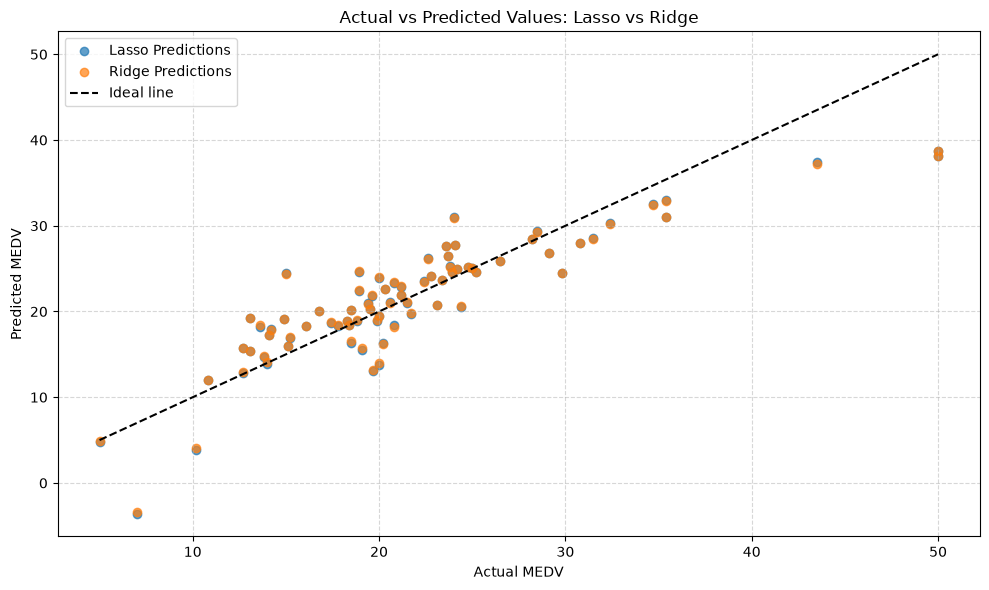

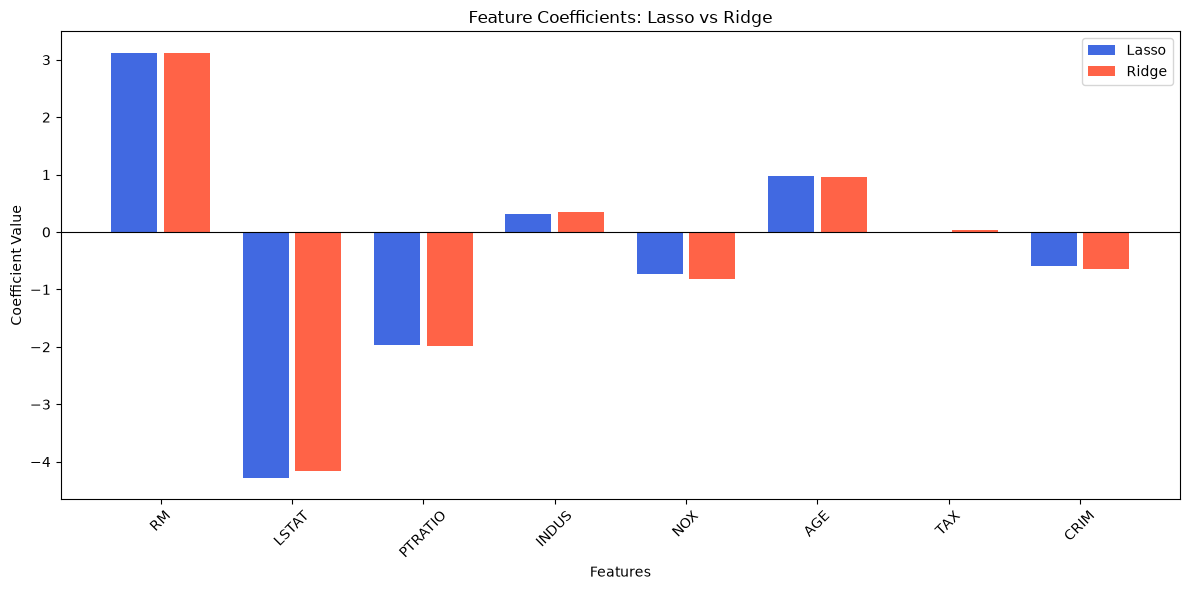

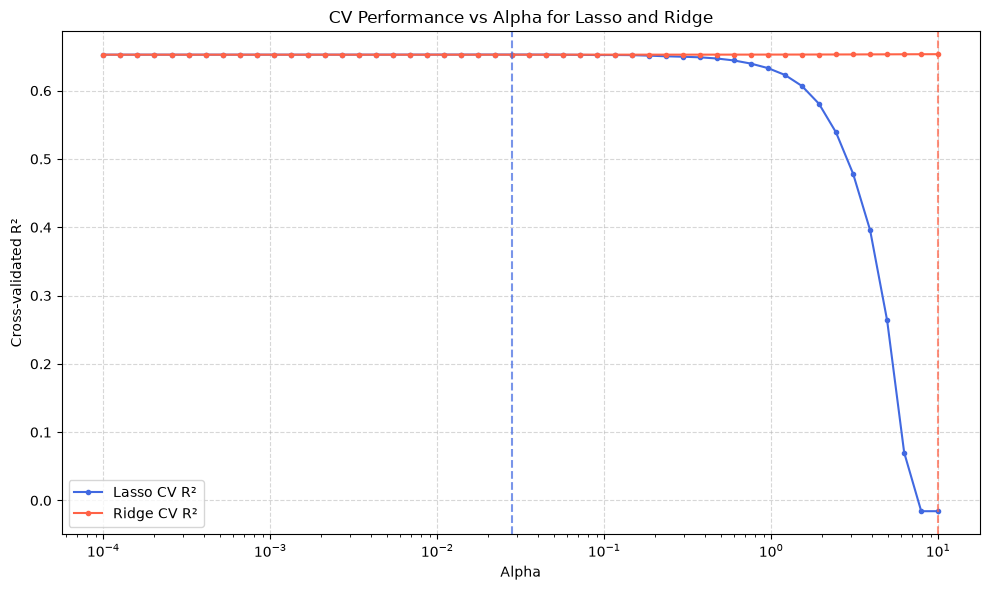

In [143]:
from sklearn.model_selection import cross_val_score

# Actual vs Predicted for Lasso and Ridge

plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.7, label='Lasso Predictions')
plt.scatter(y_test, y_pred1, alpha=0.7, label='Ridge Predictions')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', lw=1.5, label='Ideal line')

plt.xlabel('Actual MEDV')
plt.ylabel('Predicted MEDV')
plt.title('Actual vs Predicted Values: Lasso vs Ridge')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

coef_lasso = final_model.named_steps['lasso'].coef_
coef_ridge = final_model1.named_steps['ridge'].coef_
feature_names = x.columns

x_pos = np.arange(len(feature_names))

plt.figure(figsize=(12, 6))
plt.bar(x_pos - 0.2, coef_lasso, width=0.35, label='Lasso', color='royalblue')
plt.bar(x_pos + 0.2, coef_ridge, width=0.35, label='Ridge', color='tomato')

plt.xticks(x_pos, feature_names, rotation=45)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Feature Coefficients: Lasso vs Ridge')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.legend()
plt.tight_layout()
plt.show()

lasso_cv_scores = []
ridge_cv_scores = []
for alpha in alpha_grid:
    lasso_model = make_pipeline(StandardScaler(), Lasso(alpha=alpha, max_iter=10000, random_state=42))
    ridge_model = make_pipeline(StandardScaler(), Ridge(alpha=alpha, max_iter=10000, random_state=42))

    lasso_score = cross_val_score(lasso_model, x_train, y_train, cv=5, scoring='r2').mean()
    ridge_score = cross_val_score(ridge_model, x_train, y_train, cv=5, scoring='r2').mean()

    lasso_cv_scores.append(lasso_score)
    ridge_cv_scores.append(ridge_score)

plt.figure(figsize=(10, 6))
plt.plot(alpha_grid, lasso_cv_scores, label='Lasso CV R²', color='royalblue', marker='o', markersize=3)
plt.plot(alpha_grid, ridge_cv_scores, label='Ridge CV R²', color='tomato', marker='o', markersize=3)
plt.axvline(best_alpha, color='royalblue', linestyle='--', alpha=0.7)
plt.axvline(best_alpha1, color='tomato', linestyle='--', alpha=0.7)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Cross-validated R²')
plt.title('CV Performance vs Alpha for Lasso and Ridge')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Effect of alpha on model performance

The alpha value controls the strength of regularization. When alpha is small, the model behaves more like ordinary linear regression and can fit the training data more closely. When alpha is large, the model is penalized more heavily, so the coefficients shrink toward zero and the model becomes simpler and more stable. If alpha is too large, performance may decrease because the model underfits the data.

For this dataset, the best alpha values were:
- Lasso: 0.0281
- Ridge: 10.0

This shows that regularization improves generalization, but too much regularization can reduce prediction accuracy.

## Effect of regularization on model coefficients

Regularization changes the coefficient values by adding a penalty term to the loss function.

- Lasso uses L1 regularization, which can force some coefficients exactly to zero. This helps remove irrelevant features.
- Ridge uses L2 regularization, which shrinks coefficients but usually does not set them to zero.

In this experiment:
- Lasso reduced the coefficient of TAX to zero.
- Ridge kept all coefficients non-zero but reduced their magnitude.

This means Lasso performs feature selection, while Ridge keeps all features but controls their impact.

## Why feature scaling is important

Lasso and Ridge are sensitive to the scale of features because the penalty is based on coefficient size. If the features have different ranges or units, then a feature with a larger numeric scale can dominate the regularization term, causing unfair coefficient shrinking. Scaling ensures that each feature contributes fairly to the penalty and improves the stability of the model.

That is why we used:
- StandardScaler()
- inside the pipeline before Lasso and Ridge

## Which model is more suitable?

Based on the experimental results:

| Model | MAE | MSE | RMSE | R² |
|---|---:|---:|---:|---:|
| Linear Regression | 2.813424 | 14.905530 | 3.860768 | 0.771751 |
| Lasso Regression | 2.796960 | 14.637332 | 3.825877 | 0.775858 |
| Ridge Regression | 2.797187 | 14.588557 | 3.819497 | 0.776605 |

Ridge gives the best overall performance because it has the lowest MSE, lowest RMSE, and highest R². Lasso is close behind and offers the advantage of feature selection by setting one coefficient to zero.

Therefore, for this dataset:
- Ridge is more suitable when the main goal is prediction accuracy.
- Lasso is more suitable when the main goal is simplicity and interpretation.
